<a href="https://colab.research.google.com/github/asegura4488/EDCO_IntroCienciaDatos/blob/main/Semana3/ProbabilidadKDE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde
from scipy.integrate import quad

In [54]:
# crear datos sinteticos ->
# hacer una encuesta -> correr un simulación y tomar datos
# variable aleatoria -> muestreo debe ser aleatorio
# X es la muestra completa
x = np.random.randint(0,2,10000)
#x

(array([4983.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
        5017.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

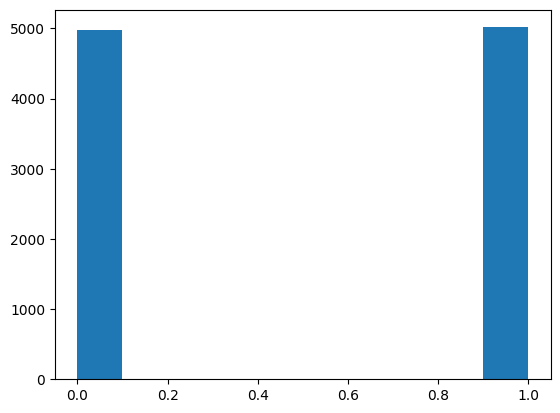

In [55]:
plt.hist(x)

In [58]:
# Hacer un filtrado
mask = x == 0
favorables = x[mask]
#favorables

In [59]:
probabilidad = np.shape(favorables)[0]/np.shape(x)[0]
probabilidad

0.4983

In [60]:
def frecuencia(n):

  x = np.random.randint(1,7,int(n))

  A = x[ x == 5 ]

  favorables = np.shape(A)[0]

  #print(n)

  return favorables/n

In [61]:
np.logspace(1,7,10)

array([1.00000000e+01, 4.64158883e+01, 2.15443469e+02, 1.00000000e+03,
       4.64158883e+03, 2.15443469e+04, 1.00000000e+05, 4.64158883e+05,
       2.15443469e+06, 1.00000000e+07])

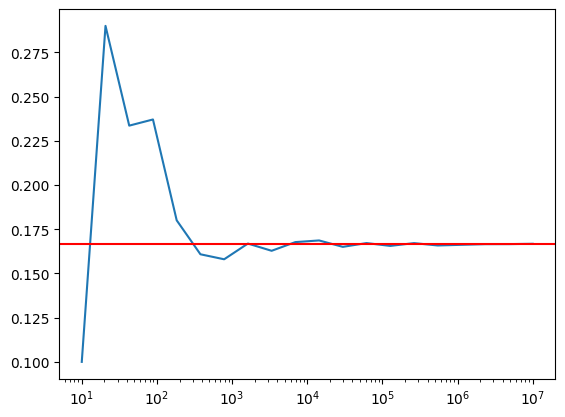

In [64]:
x = np.logspace(1,7,20)
prob = x.copy()
for i in range(len(x)):
  prob[i] = frecuencia(x[i])
plt.plot(x,prob)
plt.xscale("log")
plt.axhline(y=1/6,color='r')
#plt.yscale("log")
plt.show()

Probabilidad en el rango [10, 20] (Segundo Pico):
- Histograma: 0.5350 (53.50%)
- KDE:        0.5256 (52.56%)
- Diferencia: 0.0094


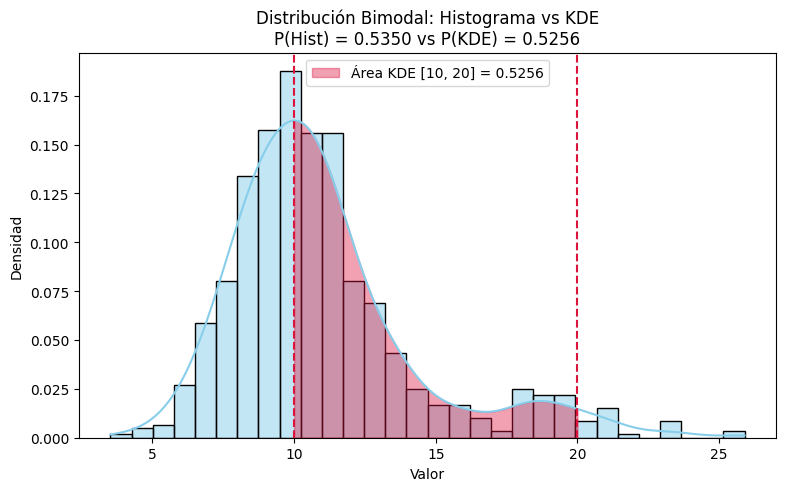

In [76]:
# 1. Generar datos con DOS PICOS (Pico 1 alrededor de 10, Pico 2 alrededor de 18)
np.random.seed(42)
# Crear muestras identicas
pico1 = np.random.normal(loc=10, scale=2, size=700)
pico2 = np.random.normal(loc=18, scale=3, size=100)
datos = np.concatenate([pico1, pico2])

# 2. Definir rango de interés [a, b] sobre el SEGUNDO PICO
a, b = 10, 20

# -------------------------------------------------------------
# 3. CÁLCULO DE PROBABILIDADES EN EL RANGO [15, 21]
# -------------------------------------------------------------

# A) Probabilidad con HISTOGRAMA (frecuencia relativa en el rango)
prob_hist = np.mean((datos >= a) & (datos <= b))

# B) Probabilidad con KDE (área integrada bajo la curva)
kde = gaussian_kde(datos)
prob_kde, _ = quad(kde.evaluate, a, b)

print(f"Probabilidad en el rango [{a}, {b}] (Segundo Pico):")
print(f"- Histograma: {prob_hist:.4f} ({prob_hist*100:.2f}%)")
print(f"- KDE:        {prob_kde:.4f} ({prob_kde*100:.2f}%)")
print(f"- Diferencia: {abs(prob_hist - prob_kde):.4f}")

# -------------------------------------------------------------
# 4. GRÁFICA EN JUPYTER
# -------------------------------------------------------------
plt.figure(figsize=(9, 5))

# Graficar Histograma + KDE
sns.histplot(datos, bins=30, stat="density", kde=True, color="skyblue")

# Sombrear el área del KDE en el segundo pico [15, 21]
x_area = np.linspace(a, b, 200)
plt.fill_between(x_area, kde.evaluate(x_area), color='crimson', alpha=0.4,
                 label=f'Área KDE [{a}, {b}] = {prob_kde:.4f}')

# Líneas verticales del intervalo
plt.axvline(a, color="crimson", linestyle="--", linewidth=1.5)
plt.axvline(b, color="crimson", linestyle="--", linewidth=1.5)

plt.title(f"Distribución Bimodal: Histograma vs KDE\nP(Hist) = {prob_hist:.4f} vs P(KDE) = {prob_kde:.4f}")
plt.xlabel("Valor")
plt.ylabel("Densidad")
plt.legend()
plt.show()

Total de transacciones: 1000
Anomalías detectadas:   20

Ejemplo de transacciones marcadas como anomalía:


,monto_cop,densidad_prob,es_anomalia
980,1.280786e+07,2.730397e-09,True
981,9.786721e+06,5.730551e-09,True
982,3.494129e+06,1.971531e-09,True
983,3.220145e+06,1.971531e-09,True
984,1.382515e+07,2.691192e-09,True


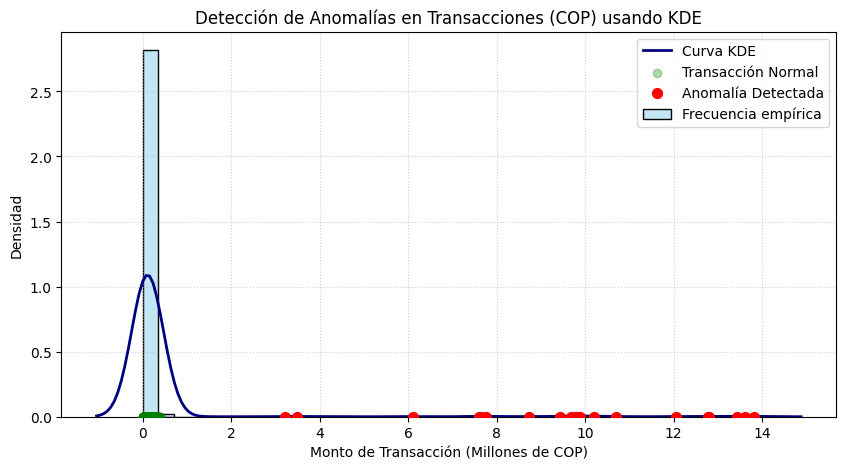

In [ ]:
# Caso de transacciones irregulares
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde

# 1. GENERAR DATOS SINTÉTICOS DE TRANSACCIONES EN COP
np.random.seed(42)

# Transacciones normales (ej. compras cotidianas entre $20,000 y $300,000 COP)
compras_habituales = np.random.gamma(shape=2, scale=50_000, size=980) + 10_000

# Anomalías (montos atípicos altos ej. $2,000,000 a $15,000,000 COP)
anomalias = np.random.uniform(low=2_000_000, high=15_000_000, size=20)

# Unir todas las transacciones
montos_cop = np.concatenate([compras_habituales, anomalias])

# Crear DataFrame
df = pd.DataFrame({'monto_cop': montos_cop})

# -------------------------------------------------------------
# 2. MODELAR DENSIDAD EMPÍRICA (KDE) Y DETECTAR ANOMALÍAS
# -------------------------------------------------------------

# Estimación de densidad por Kernel (KDE)
kde = gaussian_kde(df['monto_cop'])

# Calcular la densidad de probabilidad para cada transacción
df['densidad_prob'] = kde(df['monto_cop'])

# Definir umbral: marcar como anomalía el 2% de menor probabilidad
umbral_densidad = np.percentile(df['densidad_prob'], 2)
df['es_anomalia'] = df['densidad_prob'] < umbral_densidad

# Mostrar resúmenes
print(f"Total de transacciones: {len(df)}")
print(f"Anomalías detectadas:   {df['es_anomalia'].sum()}")
print("\nEjemplo de transacciones marcadas como anomalía:")
display(df[df['es_anomalia']].head())

# -------------------------------------------------------------
# 3. VISUALIZACIÓN EN JUPYTER
# -------------------------------------------------------------
plt.figure(figsize=(10, 5))

# Distribución normal (en millones de COP para fácil lectura)
sns.histplot(df['monto_cop'] / 1e6, bins=40, stat="density", color="skyblue", alpha=0.5, label="Frecuencia empírica")
sns.kdeplot(df['monto_cop'] / 1e6, color="navy", lw=2, label="Curva KDE")

# Graficar puntos normales vs anomalías
anomalias_df = df[df['es_anomalia']]
normales_df = df[~df['es_anomalia']]

plt.scatter(normales_df['monto_cop'] / 1e6, np.zeros(len(normales_df)),
            color='green', alpha=0.3, label='Transacción Normal', zorder=3)
plt.scatter(anomalias_df['monto_cop'] / 1e6, np.zeros(len(anomalias_df)),
            color='red', s=50, label='Anomalía Detectada', zorder=4)

#plt.xscale('log')
#plt.yscale('log')

plt.title("Detección de Anomalías en Transacciones (COP) usando KDE")
plt.xlabel("Monto de Transacción (Millones de COP)")
plt.ylabel("Densidad")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)
plt.show()